In [1]:
import os
import h5py
import numpy as np
import tensorflow as tf
import os
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:

IMG_H5 = r"C:\Users\ytsub\Desktop\github\Byte-The-Storm\data\cyclone dataset\Cyclone_Images.h5"
LABEL_NPY = r"C:\Users\ytsub\Desktop\github\Byte-The-Storm\data\cyclone dataset\Cyclone_Labels h5.npy"

In [ ]:
## RESNET

Backbone trainable: False
Head dense trainable: True
Predictions trainable: True


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resizing (Resizing)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dense_128 (Dense)               │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 667s 1s/step - accuracy: 0.3176 - loss: 1.6426 - val_accuracy: 0.3392 - val_loss: 1.6049
Epoch 2/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - accuracy: 0.3354 - loss: 1.6111 - val_accuracy: 0.3392 - val_loss: 1.5920
Epoch 3/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - accuracy: 0.3374 - loss: 1.5873 - val_accuracy: 0.3392 - val_loss: 1.5630
Epoch 4/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - accuracy: 0.3448 - loss: 1.5546 - val_accuracy: 0.3392 - val_loss: 1.5207
Epoch 5/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 650s 1s/step - accuracy: 0.3587 - loss: 1.5035 - val_accuracy: 0.3662 - val_loss: 1.4626
Epoch 6/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 674s 1s/step - accuracy: 0.3747 - loss: 1.4565 - val_accuracy: 0.3399 - val_loss: 1.5710
Epoch 7/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 680s 1s/step - accuracy: 0.3901 - loss: 1.4182 - val_accuracy: 0.4056 - val_loss: 1.4438
Epoch 8/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - accuracy: 0.4049 - loss: 1.3894 - val_accu

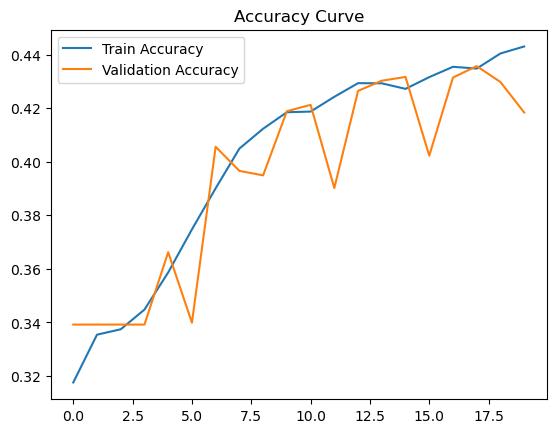

In [3]:
with h5py.File(IMG_H5, "r") as f:
    images = np.array(f["Images"])

labels = np.load(LABEL_NPY, allow_pickle=True)

def extract_wind_speed(row):
    try:
        return float(row[5])
    except:
        return np.nan

wind_speeds = np.array([extract_wind_speed(row) for row in labels])

def classify_cyclone(speed):
    if speed < 31:
        return "Low Pressure"
    elif 31 <= speed <= 49: 
        return "Depression"
    elif 49 < speed <= 61:
        return "Deep Depression"
    elif 61 < speed <= 88:
        return "Cyclonic Storm"
    elif 88 < speed <= 117:
        return "Severe Cyclonic Storm"
    elif 117 < speed <= 221:
        return "Very Severe Cyclonic Storm"
    else:
        return "Super Cyclone"

cyclone_classes = np.array([classify_cyclone(ws) for ws in wind_speeds])
unique_classes = np.unique(cyclone_classes)
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
labels_int = np.array([class_to_idx[c] for c in cyclone_classes])

images = images.astype("float32")
if images.shape[-1] != 3:
    images = images[..., :3]
images = images / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    images, labels_int, test_size=0.2, random_state=42, stratify=labels_int
)

BATCH_SIZE = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

IMG_SIZE = 224
num_classes = len(unique_classes)

# Build backbone and model
base_model = ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze backbone
base_model.trainable = False

# Build classifier head separately so we can be explicit about trainable flags
inputs = layers.Input(shape=(128, 128, 3), dtype=tf.float32)
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu", name="head_dense_128")(x)
outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

model = models.Model(inputs, outputs)

# Ensure classifier head layers are trainable (explicit)
for layer in model.layers:
    if layer.name in ("head_dense_128", "predictions"):
        layer.trainable = True

# Double-check: backbone frozen, head trainable
print("Backbone trainable:", base_model.trainable)
print("Head dense trainable:", model.get_layer("head_dense_128").trainable)
print("Predictions trainable:", model.get_layer("predictions").trainable)

# Compile AFTER setting trainable flags
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Show summary (trainable params should be > 0)
model.summary()

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

plt.figure()
plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
plt.plot(history.history.get("val_accuracy", []), label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


In [4]:
model.save("cyclone_model.keras")

In [ ]:
#cnn

In [ ]:
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -----------------------------
# DATA LOADING
# -----------------------------
DATA_PATH = "/kaggle/input/thecycloneimagedataset"
IMG_H5 = os.path.join(DATA_PATH, "Cyclone_Images.h5")
LABEL_NPY = os.path.join(DATA_PATH, "Cyclone_Labels h5.npy")

with h5py.File(IMG_H5, "r") as f:
    images = np.array(f["Images"])   # shape expected (N,H,W,3)

labels = np.load(LABEL_NPY, allow_pickle=True)

# -----------------------------
# WIND SPEED EXTRACTION
# Column 5 = wind speed in knots
# -----------------------------
def extract_wind_speed(row):
    try:
        return float(row[5])
    except:
        return np.nan

wind_speeds = np.array([extract_wind_speed(row) for row in labels])

# -----------------------------
# CYCLONE CLASSIFICATION LOGIC
# -----------------------------
def classify_cyclone(speed):
    if speed < 31:
        return "Low Pressure"
    elif 31 <= speed <= 49:
        return "Depression"
    elif 49 < speed <= 61:
        return "Deep Depression"
    elif 61 < speed <= 88:
        return "Cyclonic Storm"
    elif 88 < speed <= 117:
        return "Severe Cyclonic Storm"
    elif 117 < speed <= 221:
        return "Very Severe Cyclonic Storm"
    

cyclone_classes = np.array([classify_cyclone(ws) for ws in wind_speeds])

# ---------------------------------
# FIXED ORDER CLASS MAPPING
# ---------------------------------
ordered_classes = [
    "Low Pressure",
    "Depression",
    "Deep Depression",
    "Cyclonic Storm",
    "Severe Cyclonic Storm",
    "Very Severe Cyclonic Storm"
]

class_to_idx = {c:i for i, c in enumerate(ordered_classes)}
labels_int = np.array([class_to_idx[c] for c in cyclone_classes])

print("Class to Index Mapping:", class_to_idx)

# -----------------------------
# IMAGE NORMALIZATION
# -----------------------------
images = images.astype("float32")
if images.shape[-1] != 3:
    images = images[..., :3]
images = images / 255.0

# -----------------------------
# TRAIN-VAL SPLIT
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    images, labels_int, test_size=0.2, random_state=42, stratify=labels_int
)

BATCH_SIZE = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

IMG_SIZE = 128
num_classes = len(ordered_classes)

# -----------------------------
# CNN MODEL
# -----------------------------
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation='leaky_relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='leaky_relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='leaky_relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='leaky_relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# TRAINING
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# -----------------------------
# PLOTTING
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
plt.plot(history.history.get("val_accuracy", []), label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

val_loss, val_accuracy = model.evaluate(val_ds)
print("Final Validation Accuracy:", val_accuracy)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# Predict on the validation set
# -----------------------------
IMG_SIZE = 128  # same as model input
X_val_resized = tf.image.resize(X_val, (IMG_SIZE, IMG_SIZE))

pred_probs = model.predict(X_val_resized)
pred_indices = np.argmax(pred_probs, axis=1)

# -----------------------------
# Map indices to class names
# -----------------------------
idx_to_class = {v: k for k, v in class_to_idx.items()}  # class_to_idx from training
pred_labels = [idx_to_class[idx] for idx in pred_indices]
actual_labels = [idx_to_class[idx] for idx in y_val]

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_val, pred_indices)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx_to_class.values()))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix on Validation Set")
plt.show()

# -----------------------------
# Display some validation images with predictions
# -----------------------------
num_samples = 10  # number of images to display
for i in range(num_samples):
    plt.imshow(X_val[i])
    plt.title(f"Actual: {actual_labels[i]} | Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()

# -----------------------------
# Compute overall validation accuracy
# -----------------------------
val_accuracy = np.mean(pred_indices == y_val)
print("Validation Accuracy:", val_accuracy)